<a href="https://colab.research.google.com/github/samritha07/Deep-Learning/blob/main/Single_layer_perceptron_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        self.weights = np.zeros(n_inputs)
        self.bias = 0
        self.lr = lr

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        linear_output = np.dot(x, self.weights) + self.bias
        return self.activation(linear_output)

    def train(self, X, y, epochs=20):
        for _ in range(epochs):
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction

                self.weights += self.lr * error * xi
                self.bias += self.lr * error

In [2]:
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

and_model = Perceptron(2)
and_model.train(X_and, y_and, epochs=20)

print("AND Gate Predictions:")
for x in X_and:
    print(x, "->", and_model.predict(x))

AND Gate Predictions:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


In [3]:
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

or_model = Perceptron(2)
or_model.train(X_or, y_or, epochs=20)

print("\nOR Gate Predictions:")
for x in X_or:
    print(x, "->", or_model.predict(x))


OR Gate Predictions:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


In [4]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred) * 100

pred_and = [and_model.predict(x) for x in X_and]
pred_or = [or_model.predict(x) for x in X_or]

print("\nAND Accuracy:", accuracy(y_and, pred_and), "%")
print("OR Accuracy:", accuracy(y_or, pred_or), "%")


AND Accuracy: 100.0 %
OR Accuracy: 100.0 %


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [7]:
class Perceptron:
    def __init__(self, n_inputs, lr=0.01):
        self.weights = np.zeros(n_inputs)
        self.bias = 0
        self.lr = lr

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        linear_output = np.dot(x, self.weights) + self.bias
        return self.activation(linear_output)

    def train(self, X, y, epochs=100):
        for _ in range(epochs):
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction

                self.weights += self.lr * error * xi
                self.bias += self.lr * error

In [8]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

print("Dataset Shape:", X.shape)

Dataset Shape: (1000, 2)


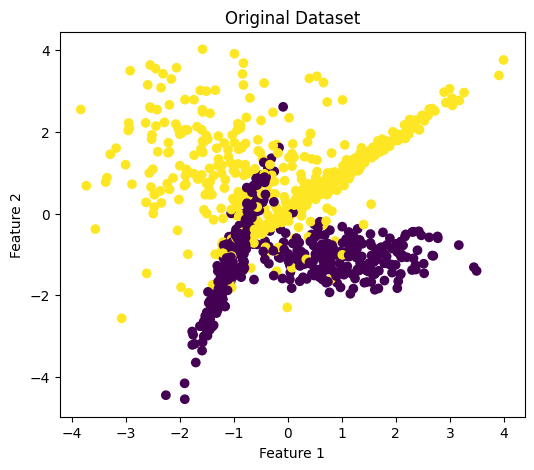

In [9]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Original Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = Perceptron(n_inputs=2, lr=0.01)

model.train(
    X_train,
    y_train,
    epochs=100
)

print("Training Complete")

Training Complete


In [13]:
y_pred = [model.predict(x) for x in X_test]

accuracy = accuracy_score(y_test, y_pred)

print("Perceptron Accuracy =", round(accuracy*100,2), "%")

Perceptron Accuracy = 64.0 %


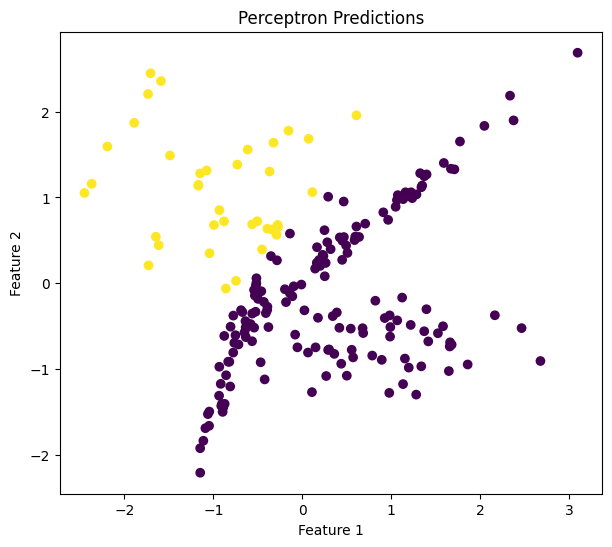

In [14]:
plt.figure(figsize=(7,6))

plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=y_pred,
    marker='o'
)

plt.title("Perceptron Predictions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

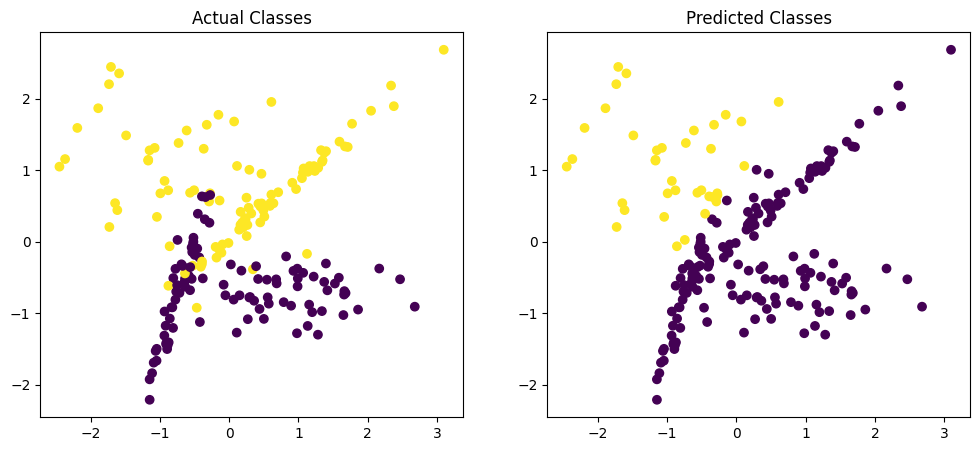

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test)
plt.title("Actual Classes")

plt.subplot(1,2,2)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)
plt.title("Predicted Classes")

plt.show()